# SMARD Germany — Day-Ahead Price Forecasting

Predicts all 24 hourly Day-Ahead prices for the German market (EPEX Spot DE/LU) using XGBoost.

Run around 11:00–11:30 Berlin time, before the EPEX auction at 12:00. By then we have actual generation data up to ~hour 10–11 today, plus TSO forecasts for tomorrow — that combination is much richer than forecasts alone.

In [1]:
import sys
!{sys.executable} -m pip install shap xgboost scikit-learn joblib holidays optuna lightgbm --quiet

**XGBoost config notes:**
- `n_estimators=5000` with early stopping — it finds the right cutoff automatically
- `learning_rate=0.00851` — tuned by Optuna, conservative to avoid overfitting on noisy price data
- `min_child_weight=5` — stops the model from treating individual price spikes as real patterns

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")
import requests
from smard_cache import init_db, fetch_feature_cached, get_db_stats, get_connection
init_db()
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
)

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", None)

print("Libraries loaded.")
print(f"XGBoost version : {xgb.__version__}")
print(f"SHAP version    : {shap.__version__}")

DB initialized → smard_cache.db
Libraries loaded.
XGBoost version : 3.2.0
SHAP version    : 0.51.0


In [3]:
# hyperparams — tuned by Optuna (see tuning cell below)
XGB_PARAMS = {
    "objective":             "reg:squarederror",
    "eval_metric":           "rmse",
    "early_stopping_rounds": 200,
    "n_estimators":          5000,
    "learning_rate":        0.00851,
    "max_depth":             6,
    "subsample":             0.635,
    "colsample_bytree":      0.564,
    "min_child_weight":      5,
    "reg_alpha":             0.907,
    "reg_lambda":            4.593,
    "random_state":          42,
    "n_jobs":                -1,
}
N_CV_FOLDS = 5
BASE_URL = "https://www.smard.de/app/chart_data"
HEADERS  = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept":  "application/json",
    "Referer": "https://www.smard.de/",
}


N_WEEKS = 156  # 3 years


# chronological split — no shuffling on time series
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15

In [4]:
# SMARD API helpers
def get_timestamps(fid, region):
    try:
        r = requests.get(
            f"{BASE_URL}/{fid}/{region}/index_hour.json",
            headers=HEADERS, timeout=10
        )
        r.raise_for_status()
        return r.json().get("timestamps", [])
    except Exception:
        return []


def get_series(fid, region, bucket):
    try:
        r = requests.get(
            f"{BASE_URL}/{fid}/{region}/{fid}_{region}_hour_{bucket}.json",
            headers=HEADERS, timeout=10
        )
        r.raise_for_status()
        return r.json().get("series", [])
    except Exception:
        return []


def fetch_feature(name, fid, region):
    buckets = sorted(get_timestamps(fid, region), reverse=True)[:N_WEEKS]
    rows = []
    for b in sorted(buckets):
        rows.extend(get_series(fid, region, b))
    if not rows:
        raise ValueError(f"empty stream {fid}/{region}")
    s = pd.DataFrame(rows, columns=["ts", name])
    s["ts"] = pd.to_datetime(s["ts"], unit="ms", utc=True)
    s = s.set_index("ts")[name]
    s = s[~s.index.duplicated(keep="last")]
    last_valid = s.last_valid_index()
    return s[:last_valid] if last_valid else s

In [5]:
# run this only when changing N_WEEKS
import os
if os.path.exists("smard_cache.db"):
    os.remove("smard_cache.db")
    print("Cache deleted — will re-download all data")
else:
    print("No cache found")

# Re-initialize DB after deletion
from smard_cache import init_db
init_db()
print("DB re-initialized")

Cache deleted — will re-download all data
DB initialized → smard_cache.db
DB re-initialized


### Data Download

Pulls from SMARD API: generation mix, consumption, DA prices for DE/LU and neighbours, TSO generation forecasts.

In [6]:
SMARD_FILTERS = {
    
    # actual generation
    "gen_lignite"            : (1223, "DE"),
    "gen_wind_offshore"      : (1225, "DE"),
    "gen_hydro"              : (1226, "DE"),
    "gen_other_conventional" : (1227, "DE"),
    "gen_other_renewables"   : (1228, "DE"),
    "gen_biomass"            : (4066, "DE"),
    "gen_wind_onshore"       : (4067, "DE"),
    "gen_solar"              : (4068, "DE"),
    "gen_hard_coal"          : (4069, "DE"),
    "gen_pumped_storage"     : (4070, "DE"),
    "gen_gas"                : (4071, "DE"),

    # consumption
    "cons_actual_load"       : ( 410, "DE"),
    "cons_residual_load"     : (4359, "DE"), 
    "cons_pumped_storage"    : (4387, "DE"),

    # DA prices — DE/LU and neighbours
    "price_DE_LU"            : (4169, "DE-LU"),
    "price_neighbours_avg"   : (5078, "DE-LU"),
    "price_AT"               : (4170, "DE-LU"),
    "price_BE"               : (4996, "DE-LU"),
    "price_NO2"              : (4997, "DE-LU"),
    "price_DK1"              : ( 252, "DE-LU"),
    "price_DK2"              : ( 253, "DE-LU"),
    "price_FR"               : ( 254, "DE-LU"),
    "price_NL"               : ( 256, "DE-LU"),
    "price_CH"               : ( 259, "DE-LU"),
    "price_CZ"               : ( 261, "DE-LU"),

    # TSO forecasts for tomorrow
    "forecast_wind_offshore" : (3791, "DE"),
    "forecast_wind_onshore"  : ( 123, "DE"),
    "forecast_solar"         : ( 126, "DE"),
    "forecast_wind_solar"    : (5097, "DE"),
    "forecast_gen_total"     : ( 122, "DE"),
}


print("Downloading from SMARD...")

series_map = {}
skipped    = []

for feat, (fid, region) in SMARD_FILTERS.items():
    try:
        s = fetch_feature_cached(feat, fid, region, fetch_feature, N_WEEKS)
        series_map[feat] = s
    except Exception:
        print(f"  --  {feat} (skipped)")
        skipped.append(feat)

get_db_stats()
print()

r = requests.get(
    "https://www.smard.de/app/chart_data/4169/DE-LU/index_hour.json",
    headers=HEADERS, timeout=10
)
timestamps = r.json().get("timestamps", [])
latest = max(timestamps)
print(f"Latest SMARD bucket: {pd.Timestamp(latest, unit='ms', tz='UTC').tz_convert('Europe/Berlin')}")

  FETCH  gen_lignite                       (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_wind_offshore                 (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_hydro                         (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_other_conventional            (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_other_renewables              (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_biomass                       (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_wind_onshore                  (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_solar                         (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_hard_coal                     (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_pumped_storage                (not in cache)
           → saved 26203 new rows to DB
  FETCH  gen_gas    

### Data Assembly

In [7]:
df_raw = pd.concat(series_map.values(), axis=1, keys=series_map.keys())
df_raw.sort_index(inplace=True)
df_raw.index = df_raw.index.tz_convert("Europe/Berlin")
df_raw.index.name = "timestamp"

# Separate actual (past) and forecast (future-facing) columns
actual_cols   = [c for c in df_raw.columns if c.startswith("gen_")
                                            or c.startswith("cons_")]
forecast_cols = [c for c in df_raw.columns if c.startswith("forecast_")]
price_cols    = [c for c in df_raw.columns if c.startswith("price_")]
print(df_raw.shape)

(26232, 30)


### Feature Engineering

In [8]:
# at prediction time (11:30): actual data up to ~hour 10-11, forecasts for tomorrow
df = df_raw.copy()
 
p = df["price_DE_LU"]
 
# price lags — no leakage
df["price_lag_24h"]  = p.shift(24)    # same hour yesterday — very strong feature
df["price_lag_48h"]  = p.shift(48)
df["price_lag_168h"] = p.shift(168)   # same hour last week
 
# rolling stats — shift(1) to stay consistent with train/test logic
p_lagged = p.shift(1)
df["price_rolling_24h_mean"] = p_lagged.rolling(24,  min_periods=6).mean().round(3)
df["price_rolling_24h_std"]  = p_lagged.rolling(24,  min_periods=6).std().round(3)
df["price_rolling_7d_mean"]  = p_lagged.rolling(168, min_periods=24).mean().round(3)
 
# neighbour prices not available at 11:30 — use lag-24h, no leakage
if "price_neighbours_avg" in df.columns:
    # use lag-24h for both sides — neighbours not available at 11:30
    df["price_spread_vs_eu"] = (p.shift(24) - df["price_neighbours_avg"].shift(24)).round(3)
 
for col in ["price_AT", "price_BE", "price_NO2", "price_DK1", "price_DK2",
            "price_FR", "price_NL", "price_CH", "price_CZ", "price_neighbours_avg"]:
    if col in df.columns:
        df[f"{col}_lag24"] = df[col].shift(24)
 
if "price_FR" in df.columns and "price_DE_LU" in df.columns:
    df["fr_de_spread"] = (
        df["price_FR"].shift(24) - df["price_DE_LU"].shift(24)
    ).round(3)
 
 
# today's actual situation — shapes tomorrow's auction expectations
if "cons_actual_load" in df.columns:
    lo = df["cons_actual_load"]
    df["load_today_mean"]    = lo.rolling(12, min_periods=3).mean().round(1)
    df["load_today_trend"]   = (lo - lo.shift(6)).round(1)   # rising or falling
    df["load_lag_24h"]       = lo.shift(24)
 
if "gen_solar" in df.columns:
    df["solar_today_peak"]   = df["gen_solar"].rolling(12, min_periods=3).max().round(1)
 
if "gen_wind_onshore" in df.columns and "gen_wind_offshore" in df.columns:
    df["wind_total_now"]     = (df["gen_wind_onshore"] + df["gen_wind_offshore"]).round(1)
    df["wind_today_mean"]    = df["wind_total_now"].rolling(12, min_periods=3).mean().round(1)
 
# Renewable share at this moment in the day
ren_cols  = [c for c in df.columns if any(k in c for k in
             ["wind_total", "gen_solar", "gen_hydro", "gen_biomass"])]
if ren_cols and "cons_actual_load" in df.columns:
    safe_load = df["cons_actual_load"].replace(0, np.nan)
    df["renewable_share_now"] = (
        df[ren_cols].sum(axis=1, min_count=1) / safe_load * 100
    ).round(2)
 
 
# forecast_solar from SMARD is ~3x inflated — scale down
if "forecast_solar" in df.columns:
    df["forecast_solar"] = (df["forecast_solar"].abs() / 3.0).round(1)
    
if "forecast_wind_solar" in df.columns:
    df["forecast_wind_solar"] = df["forecast_wind_solar"].abs()
 
# rebuild wind+solar from components — SMARD's combined filter is inflated
if "forecast_wind_offshore" in df.columns and "forecast_wind_onshore" in df.columns:
    df["forecast_wind_solar_calc"] = (
        df["forecast_wind_offshore"] +
        df["forecast_wind_onshore"] +
        df["forecast_solar"]
    ).round(1)
 
ws = df["forecast_wind_solar_calc"] if "forecast_wind_solar_calc" in df.columns \
     else df["forecast_wind_solar"]
 
# renewable ratio
if "forecast_gen_total" in df.columns:
    safe_gen = df["forecast_gen_total"].replace(0, np.nan)
    df["forecast_renewable_ratio"] = (ws / safe_gen).round(4)
 
# residual load proxy — total gen minus renewables, key merit-order signal
if "forecast_gen_total" in df.columns:
    df["residual_conventional_proxy"] = (
        df["forecast_gen_total"] - ws
    ).round(1)
 
# forecast deltas — direction of change often matters more than absolute level
# (SMARD indexes by delivery hour, not publication time — this is an approximation)
if "forecast_wind_solar_calc" in df.columns:
    df["forecast_wind_solar_delta_6h"]  = (
        df["forecast_wind_solar_calc"] - df["forecast_wind_solar_calc"].shift(6)
    ).round(1)
    df["forecast_wind_solar_delta_12h"] = (
        df["forecast_wind_solar_calc"] - df["forecast_wind_solar_calc"].shift(12)
    ).round(1)
 
if "forecast_solar" in df.columns:
    df["forecast_solar_delta_6h"] = (
        df["forecast_solar"] - df["forecast_solar"].shift(6)
    ).round(1)
 
if "forecast_gen_total" in df.columns:
    df["forecast_total_delta_12h"] = (
        df["forecast_gen_total"] - df["forecast_gen_total"].shift(12)
    ).round(1)
 
 
# time features — today (context) and tomorrow (target day)
df["hour"]            = df.index.hour          # which hour of today are we at
df["today_dow"]       = df.index.dayofweek     # today's weekday (0=Mon)
df["today_month"]     = df.index.month
df["is_today_night"]  = ((df["hour"] >= 22) | (df["hour"] < 6)).astype(int)
 
tomorrow_dow          = (df.index + pd.Timedelta(days=1)).dayofweek
tomorrow_month        = (df.index + pd.Timedelta(days=1)).month
 
df["tomorrow_dow"]    = tomorrow_dow
df["tomorrow_month"]  = tomorrow_month
df["is_weekend_tomorrow"] = (tomorrow_dow >= 5).astype(int)
 
# cyclical encoding — sin/cos for unique (day, month) pairs
df["tomorrow_dow_sin"]   = np.sin(2 * np.pi * tomorrow_dow   / 7 ).round(4)
df["tomorrow_dow_cos"]   = np.cos(2 * np.pi * tomorrow_dow   / 7 ).round(4)
df["tomorrow_month_sin"] = np.sin(2 * np.pi * tomorrow_month / 12).round(4)
df["tomorrow_month_cos"] = np.cos(2 * np.pi * tomorrow_month / 12).round(4)
 
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24).round(4)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24).round(4)
 
 
# German holidays and bridge days
import holidays as hd
 
de_holidays = hd.Germany(years=df.index.year.unique().tolist())
 
tomorrow_idx = df.index + pd.Timedelta(days=1)  # Adds 1 day to every timestamp
 
df["is_holiday_tomorrow"] = tomorrow_idx.normalize().map(
        lambda d: 1 if d.date() in de_holidays else 0
).astype(int)
 
df["is_holiday_today"] = df.index.normalize().map(
    lambda d: 1 if d.date() in de_holidays else 0
).astype(int)
 
# bridge day: between a holiday and a weekend
df["is_bridge_day_tomorrow"] = (
    (df["is_holiday_tomorrow"] == 0) &            # tomorrow is not a holiday
    (tomorrow_idx.dayofweek.isin([0,1,2,3,4])) &  # tomorrow is a weekday
    (
        # day after tomorrow is a holiday
        (tomorrow_idx + pd.Timedelta(days=1)).normalize().map(
            lambda d: 1 if d.date() in de_holidays else 0
        ).astype(bool) |
        # day before tomorrow (today) is a holiday
        df["is_holiday_today"].astype(bool)
    )
).astype(int)
 
 
# interaction features
if "forecast_wind_solar_calc" in df.columns:
        df["wind_solar_x_weekend"] = (
        df["forecast_wind_solar_calc"] * df["is_weekend_tomorrow"]
    ).round(1)
 
 
# target: price 24h ahead — last 24 rows have NaN (tomorrow, unknown)
df["target_price_24h"] = df["price_DE_LU"].shift(-24)
 
df_live = df[df["target_price_24h"].isna()].tail(24).copy()
 
 
FEATURE_COLS = [
    # neighbours lag-24h
    "price_AT_lag24", "price_BE_lag24",
    "price_NO2_lag24", "price_DK1_lag24", "price_DK2_lag24",
    "price_FR_lag24", "price_NL_lag24",
    "price_CH_lag24", "price_CZ_lag24",
    "price_neighbours_lag24",
 
    # today's actual
    "load_today_mean", "load_today_trend", "load_lag_24h",
    "solar_today_peak",
    "wind_today_mean", "wind_total_now",
    "renewable_share_now",
 
    # tomorrow's forecasts
    "forecast_wind_offshore", "forecast_wind_onshore",
    "forecast_solar", "forecast_wind_solar_calc",   # calc = rebuilt, not inflated
    "forecast_gen_total", "forecast_renewable_ratio",
    "residual_conventional_proxy",
 
    # Forecast revision deltas (direction of update)
    "forecast_wind_solar_delta_6h", "forecast_wind_solar_delta_12h",
    "forecast_solar_delta_6h", "forecast_total_delta_12h",
 
    # calendar
    "is_holiday_tomorrow", "is_holiday_today", "is_bridge_day_tomorrow",
 
    # interactions
    "wind_solar_x_weekend", "fr_de_spread",
 
    # price history
    "price_lag_24h", "price_lag_48h", "price_lag_168h",
    "price_rolling_24h_mean", "price_rolling_24h_std",
    "price_rolling_7d_mean",  "price_spread_vs_eu",
 
    # time — today
    "hour",
    "today_dow", "today_month",
    "is_today_night",
 
    # time — tomorrow (target day)
    "tomorrow_dow", "tomorrow_month",
    "is_weekend_tomorrow",
    "tomorrow_dow_sin", "tomorrow_dow_cos",
    "tomorrow_month_sin", "tomorrow_month_cos",
    "hour_sin", "hour_cos",
]
 
# Drop anything that wasn't fetched or computed
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET_COL   = "target_price_24h"   # price 24h ahead — the actual DA target

### Weather Pipeline

In [9]:
# WEATHER PIPELINE (HISTORICAL + FORECAST + FEATURES)

import requests
import pandas as pd
import numpy as np
from datetime import date
import time

LAT, LON = 52.52, 13.41
archive_url  = "https://archive-api.open-meteo.com/v1/archive"
forecast_url = "https://api.open-meteo.com/v1/forecast"

end_date   = date.today().strftime("%Y-%m-%d")
start_date = df_raw.index.min().date().strftime("%Y-%m-%d")

params_hist = {
    "latitude":   LAT,
    "longitude":  LON,
    "hourly": [
        "temperature_2m", "relative_humidity_2m", "cloud_cover",
        "wind_speed_10m", "wind_gusts_10m", "surface_pressure",
        "precipitation", "shortwave_radiation",
    ],
    "timezone":   "Europe/Berlin",
    "start_date": start_date,
    "end_date":   end_date,
}


# 1. HISTORICAL WEATHER

print("Downloading HISTORICAL weather...")
try:
    r = requests.get(archive_url, params=params_hist, timeout=120)
    r.raise_for_status()
    hist = r.json()["hourly"]
    print("  OK")
except Exception as e:
    print(f"  Failed: {e}")
    print("  Skipping weather pipeline — model will train without weather features")
    hist = None

if hist:
    weather_hist = pd.DataFrame({
        "timestamp"      : pd.to_datetime(hist["time"]),
        "temp_C"         : hist["temperature_2m"],
        "humidity"       : hist["relative_humidity_2m"],
        "cloud_cover"    : hist["cloud_cover"],
        "wind_speed"     : hist["wind_speed_10m"],
        "wind_gusts"     : hist["wind_gusts_10m"],
        "pressure"       : hist["surface_pressure"],
        "precipitation"  : hist["precipitation"],
        "solar_radiation": hist["shortwave_radiation"],
    }).set_index("timestamp")

    weather_hist.index = (
        weather_hist.index.tz_localize("UTC").tz_convert("Europe/Berlin")
    )
    print(f"  {len(weather_hist):,} rows  "
          f"({weather_hist.index[0].date()} → {weather_hist.index[-1].date()})")


# 2. FORECAST WEATHER

params_fc = {
    "latitude":      LAT,
    "longitude":     LON,
    "hourly":        ["temperature_2m", "wind_speed_10m", "shortwave_radiation"],
    "forecast_days": 2,
    "timezone":      "Europe/Berlin",
}

print("Downloading FORECAST weather...")
try:
    r = requests.get(forecast_url, params=params_fc, timeout=60)
    r.raise_for_status()
    fc = r.json()["hourly"]
    print("  OK")
except Exception as e:
    print(f"  Failed: {e}")
    fc = None

if fc:
    weather_fc = pd.DataFrame({
        "timestamp"              : pd.to_datetime(fc["time"]),
        "temp_forecast_24h"      : fc["temperature_2m"],
        "wind_speed_forecast_24h": fc["wind_speed_10m"],
        "solar_forecast_24h"     : fc["shortwave_radiation"],
    }).set_index("timestamp")

    weather_fc.index = (
        weather_fc.index.tz_localize("UTC").tz_convert("Europe/Berlin")
    )
    print(f"  {len(weather_fc):,} rows  "
          f"({weather_fc.index[0].date()} → {weather_fc.index[-1].date()})")

# 3. MERGE — only if download succeeded

if hist:
    cols_to_drop = [c for c in weather_hist.columns if c in df.columns]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
    df = df.join(weather_hist, how="left")

if fc:
    cols_to_drop = [c for c in weather_fc.columns if c in df.columns]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
    df = df.join(weather_fc, how="left")

print(f"\n  df shape after weather merge: {df.shape}")


# 4. FEATURE ENGINEERING (only if weather data available)

if hist:
    df["temp_lag_24h"]          = df["temp_C"].shift(24)
    df["wind_lag_24h"]          = df["wind_speed"].shift(24)
    df["solar_lag_24h"]         = df["solar_radiation"].shift(24)
    df["temp_rolling_24h_mean"] = df["temp_C"].shift(1).rolling(24, min_periods=6).mean()
    df["wind_rolling_12h_mean"] = df["wind_speed"].shift(1).rolling(12, min_periods=3).mean()
    df["temp_delta_6h"]         = df["temp_C"] - df["temp_C"].shift(6)
    df["wind_ramp_6h"]          = df["wind_speed"] - df["wind_speed"].shift(6)
    df["is_cold"]  = (df["temp_C"] < 5).astype(int)
    df["is_hot"]   = (df["temp_C"] > 25).astype(int)
    df["is_storm"] = (df["wind_gusts"] > 50).astype(int)
    df["solar_radiation_norm"] = (df["solar_radiation"] / 1000).round(2)
    df["solar_lag_24h_norm"]   = (df["solar_lag_24h"]   / 1000).round(2)

if fc and hist:
    df["wind_forecast_delta"] = df["wind_speed_forecast_24h"] - df["wind_lag_24h"]
    df["solar_forecast_delta"] = df["solar_forecast_24h"]     - df["solar_lag_24h"]
    df["temp_forecast_delta"]  = df["temp_forecast_24h"]      - df["temp_lag_24h"]
    df["wind_bias"]  = df["wind_forecast_delta"].shift(1).rolling(7, min_periods=3).mean()
    df["solar_bias"] = df["solar_forecast_delta"].shift(1).rolling(7, min_periods=3).mean()
    df["temp_bias"]  = df["temp_forecast_delta"].shift(1).rolling(7, min_periods=3).mean()
    df["wind_forecast_bc"]  = df["wind_speed_forecast_24h"] - df["wind_bias"]
    df["solar_forecast_bc"] = df["solar_forecast_24h"]      - df["solar_bias"]
    df["temp_forecast_bc"]  = df["temp_forecast_24h"]       - df["temp_bias"]

if hist:
    df["wind_x_weekend"]  = df["wind_speed"] * df["is_weekend_tomorrow"]
    df["cold_x_is_night"] = df["is_cold"]    * df["is_today_night"]


# 5. UPDATE FEATURE_COLS

WEATHER_FEATURES = []

if hist:
    WEATHER_FEATURES += [
        "temp_C", "temp_lag_24h", "temp_rolling_24h_mean", "temp_delta_6h",
        "wind_speed", "wind_lag_24h", "wind_rolling_12h_mean", "wind_ramp_6h",
        "is_cold", "is_hot", "is_storm",
        "solar_radiation_norm", "solar_lag_24h_norm",
        "wind_x_weekend", "cold_x_is_night",
    ]

FORECAST_ONLY_FEATURES = []
if fc and hist:
    FORECAST_ONLY_FEATURES = [
        "temp_forecast_24h", "wind_speed_forecast_24h", "solar_forecast_24h",
        "wind_forecast_delta", "solar_forecast_delta", "temp_forecast_delta",
        "wind_forecast_bc", "solar_forecast_bc", "temp_forecast_bc",
    ]

WEATHER_FEATURES = [c for c in WEATHER_FEATURES if c in df.columns]

FEATURE_COLS = FEATURE_COLS + [c for c in WEATHER_FEATURES if c not in FEATURE_COLS]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
FEATURE_COLS = [c for c in FEATURE_COLS if c not in FORECAST_ONLY_FEATURES]

print(f"Weather features added : {len(WEATHER_FEATURES)}")
print(f"Total features         : {len(FEATURE_COLS)}")
print(f"Weather features added : {len(WEATHER_FEATURES)}")
print(f"Total features         : {len(FEATURE_COLS)}")
print(f"temp_C in FEATURE_COLS: {'temp_C' in FEATURE_COLS}")
print(f"wind_speed in FEATURE_COLS: {'wind_speed' in FEATURE_COLS}")

  OK
  26,208 rows  (2023-06-05 → 2026-06-01)
  OK
  48 rows  (2026-05-31 → 2026-06-02)

  df shape after weather merge: (26232, 91)
Weather features added : 15
Total features         : 67
Weather features added : 15
Total features         : 67
temp_C in FEATURE_COLS: True
wind_speed in FEATURE_COLS: True


### Feature Selection + Train/Test Split

In [10]:
# Drop anything that wasn't fetched or computed
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET_COL   = "target_price_24h"

# Rebuild df_live AFTER weather pipeline so it has weather columns
df_live = df[df["target_price_24h"].isna()].tail(24).copy()

# Keep only rows where target and critical lags are available
critical = [TARGET_COL, "price_lag_24h", "price_lag_168h"]
df_model = df.dropna(subset=[c for c in critical if c in df.columns]).copy()

# split
n_total = len(df_model)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val  

df_train = df_model.iloc[:n_train]
df_val   = df_model.iloc[n_train:n_train + n_val]
df_test  = df_model.iloc[n_train + n_val:]

X_train, y_train = df_train[FEATURE_COLS], df_train[TARGET_COL]
X_val,   y_val   = df_val[FEATURE_COLS],   df_val[TARGET_COL]
X_test,  y_test  = df_test[FEATURE_COLS],  df_test[TARGET_COL]
X_live           = df_live[FEATURE_COLS]

# Convenience aliases
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"X_live  : {X_live.shape}")

# DATASET SUMMARY

print(f"  Target   : {TARGET_COL}")
print(f"           (price_DE_LU shifted -24h → tomorrow's DA price)")
print(f"  Total    : {n_total:,} rows")
print(f"  Train    : {n_train:,} rows  "
      f"({df_train.index[0].strftime('%Y-%m-%d')} → "
      f"{df_train.index[-1].strftime('%Y-%m-%d')})")
print(f"  Test     : {n_test:,} rows   "
      f"({df_test.index[0].strftime('%Y-%m-%d')} → "
      f"{df_test.index[-1].strftime('%Y-%m-%d')})")
print(f"  Features : {len(FEATURE_COLS)}")
if skipped:
    print(f"  Skipped  : {', '.join(skipped)}")

print("\nFeature fill rates (train set):")
for col in FEATURE_COLS:
    nn  = X_train[col].notna().sum()
    pct = nn / len(X_train) * 100
    bar = "█" * int(float(pct) / 5)
    print(f"  {col:<35} {float(pct):5.1f}%  {bar}")

print(f"\nTarget — price_DE_LU:")
print(f"  mean {y.mean():.1f}  |  std {y.std():.1f}  "
      f"|  min {y.min():.1f}  |  max {y.max():.1f}   (€/MWh DA tomorrow)")

# Show all features, grouped by category — easier to read than one wide table
pd.set_option("display.width", 130)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", None)

groups = {
    # "Neighbour prices":   [c for c in FEATURE_COLS if c.startswith("price_") and "lag" not in c and "rolling" not in c and "spread" not in c and "fr_de" not in c],
    "Neighbour prices (lag24)": [c for c in FEATURE_COLS if "lag24" in c and c.startswith("price_")],
    "Today actual":       [c for c in FEATURE_COLS if any(k in c for k in ["load_today", "solar_today", "wind_today", "wind_total", "renewable_share"])],
    "Forecasts":          [c for c in FEATURE_COLS if c.startswith("forecast_") and "delta" not in c],
    "Residual proxy":     [c for c in FEATURE_COLS if "residual" in c],
    "Forecast revisions": [c for c in FEATURE_COLS if "delta" in c],
    "Price history": [c for c in FEATURE_COLS if ("lag" in c or "rolling" in c)and not c.endswith("_lag24")and "load" not in c],
    "Spreads":            [c for c in FEATURE_COLS if "spread" in c or "fr_de" in c],
    "Holiday / calendar": [c for c in FEATURE_COLS if "holiday" in c or "bridge" in c],
    "Time (today)":       [c for c in FEATURE_COLS if c.startswith("today_") or c in ["hour","is_today_night","hour_sin","hour_cos"]],
    "Time (tomorrow)":    [c for c in FEATURE_COLS if c.startswith("tomorrow_") or c == "is_weekend_tomorrow"],
    "Interactions":       [c for c in FEATURE_COLS if "x_weekend" in c],
    "Weather (historical)": [c for c in FEATURE_COLS if any(k in c for k in 
                             ["temp_", "wind_speed", "wind_lag", "wind_rolling",
                              "solar_lag", "solar_radiation", "cloud_", 
                              "humidity", "pressure", "precipitation",
                              "is_cold", "is_hot", "is_storm", "wind_ramp",
                              "wind_x_weekend", "cold_x"])],
}

sample = df_test.tail(6)[FEATURE_COLS].copy()
sample.index = sample.index.strftime("%Y-%m-%d %H:%M")

for group_name, cols in groups.items():
    cols_present = [c for c in cols if c in sample.columns]
    if not cols_present:
        continue
    print(f"\n── {group_name} {'─' * (45 - len(group_name))}")
    print(sample[cols_present].T.to_string())

print(f"  Train    : {n_train:,} rows  "
      f"({df_train.index[0].strftime('%Y-%m-%d')} → "
      f"{df_train.index[-1].strftime('%Y-%m-%d')})")
print(f"  Val      : {len(df_val):,} rows   "
      f"({df_val.index[0].strftime('%Y-%m-%d')} → "
      f"{df_val.index[-1].strftime('%Y-%m-%d')})")
print(f"  Test     : {n_test:,} rows   "
      f"({df_test.index[0].strftime('%Y-%m-%d')} → "
      f"{df_test.index[-1].strftime('%Y-%m-%d')})")
print(f"X_live  : {df_live[FEATURE_COLS].shape}   ← these 24 rows are tomorrow's prediction targets")
print(f"Live rows : {len(df_live)}  "
      f"(latest rows with unknown tomorrow prices)")
print()
print("Next step: smard_train.py — fit XGBoost, walk-forward CV, SHAP")

X_train : (18110, 67)
X_val   : (3880, 67)
X_test  : (3882, 67)
X_live  : (24, 67)
  Target   : target_price_24h
           (price_DE_LU shifted -24h → tomorrow's DA price)
  Total    : 25,872 rows
  Train    : 18,110 rows  (2023-06-19 → 2025-07-12)
  Test     : 3,882 rows   (2025-12-21 → 2026-05-31)
  Features : 67

Feature fill rates (train set):
  price_AT_lag24                      100.0%  ████████████████████
  price_BE_lag24                      100.0%  ████████████████████
  price_NO2_lag24                     100.0%  ████████████████████
  price_DK1_lag24                     100.0%  ████████████████████
  price_DK2_lag24                     100.0%  ████████████████████
  price_FR_lag24                      100.0%  ████████████████████
  price_NL_lag24                      100.0%  ████████████████████
  price_CH_lag24                      100.0%  ████████████████████
  price_CZ_lag24                      100.0%  ████████████████████
  load_today_mean                     100.0%  

## Sanity Check

Make sure the pipeline ran before training. Failing here is better than training on wrong data.

In [11]:
# Make sure pipeline ran. If either is missing → stops immediately with a clear error message.
assert "X_train" in globals(), "Run smard_pipeline first — X_train not found."
assert "df" in globals(),      "Run smard_pipeline first — df not found."

# create target column for ALL rows (past rows get actual price, last 24 rows get NaN)
if "target_price_24h" not in df.columns:
    df["target_price_24h"] = df["price_DE_LU"].shift(-24)
    
# df_live: last 24 rows where target is NaN (tomorrow's hours, price unknown)
# we need their features
if "df_live" not in globals():
    df_live = df[df["target_price_24h"].isna()].tail(24).copy()
    print("df_live built from df.")
 
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"X_live  : {df_live[FEATURE_COLS].shape}  ← tomorrow's prediction rows")
print()
print(f"Train period : {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test  period : {X_test.index[0].date()}   →  {X_test.index[-1].date()}")
print()

print("Target statistics (actual historical prices, not predictions):")
print(f"  Train mean : {y_train.mean():.1f} €/MWh")
print(f"  Test  mean : {y_test.mean():.1f} €/MWh")
print(f"  Overall std: {y.std():.1f} €/MWh")

# Regime shift check
mean_diff = abs(y_test.mean() - y_train.mean())
if mean_diff > 30:
    print(f"\n  ⚠ WARNING: large mean difference ({mean_diff:.1f}€)")
    print(f"  → possible regime shift between train and test period")
    print(f"  → model may underperform on test set")
else:
    print(f"\n   Train/test means are close ({mean_diff:.1f}€ difference)")


X_train : (18110, 67)
X_test  : (3882, 67)
X_live  : (24, 67)  ← tomorrow's prediction rows

Train period : 2023-06-19  →  2025-07-12
Test  period : 2025-12-21   →  2026-05-31

Target statistics (actual historical prices, not predictions):
  Train mean : 84.0 €/MWh
  Test  mean : 96.2 €/MWh
  Overall std: 52.6 €/MWh

   Train/test means are close (12.2€ difference)


## Correlation Check

Find highly correlated feature pairs. XGBoost handles them fine, but they split SHAP importance — worth knowing before looking at feature importance.

In [12]:
# XGBoost is robust to correlated features — it won't break.
# But highly correlated features split importance scores between themselves,
# making SHAP harder to read. Worth knowing before presenting results.

# Compute absolute correlation matrix across all training features
corr_matrix = X_train.corr().abs()

# Keep only the upper triangle to avoid duplicate pairs (A-B and B-A)
# k=1 excludes the diagonal (a feature's correlation with itself = 1.0)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
# Extract pairs with correlation > 0.90, sorted by strength
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "corr"})
    .query("corr > 0.90")
    .sort_values("corr", ascending=False)
)

if high_corr_pairs.empty:
    print("No feature pairs with correlation > 0.90")
else:
    print(f"High-correlation pairs (> 0.90) — {len(high_corr_pairs)} found:")
    print(high_corr_pairs.to_string(index=False))

print()
print("Note: tree-based models handle correlated features well.")
print("High correlation only matters for SHAP interpretability,")
print("not for prediction accuracy.")

High-correlation pairs (> 0.90) — 24 found:
               feature_a                feature_b  corr
             today_month           tomorrow_month  0.98
          wind_total_now    forecast_wind_onshore  0.98
   forecast_wind_onshore forecast_wind_solar_calc  0.96
         price_DK1_lag24          price_DK2_lag24  0.96
          price_NL_lag24            price_lag_24h  0.96
          price_AT_lag24           price_CZ_lag24  0.95
          price_BE_lag24           price_NL_lag24  0.95
          wind_total_now forecast_wind_solar_calc  0.94
                  temp_C             temp_lag_24h  0.93
          price_AT_lag24            price_lag_24h  0.93
forecast_wind_solar_calc forecast_renewable_ratio  0.93
            temp_lag_24h    temp_rolling_24h_mean  0.93
   forecast_wind_onshore forecast_renewable_ratio  0.92
         wind_today_mean           wind_total_now  0.92
     renewable_share_now           forecast_solar  0.92
         wind_today_mean    forecast_wind_onshore  0.92
    

## Train Model

XGBoost with early stopping on the validation set.

In [13]:
print("Training final model...")

model = xgb.XGBRegressor(**XGB_PARAMS)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)


# FINAL MODEL INFO


print(f"Best iteration : {model.best_iteration}")
print(f"Best RMSE score: {model.best_score:.3f} €/MWh")


# TEST SET EVALUATION

test_preds = model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = root_mean_squared_error(y_test, test_preds)
GLOBAL_MAE_BAND = test_mae
print("\nTest-set performance:")

print(f"Test MAE  : {test_mae:.2f} €/MWh")
print(f"Test RMSE : {test_rmse:.2f} €/MWh")


# PREDICTION TABLE WITH UNCERTAINTY RANGE

predictions_df = pd.DataFrame({
    "actual"    : y_test,
    "predicted" : test_preds,
}, index=y_test.index)
predictions_df.index = predictions_df.index + pd.Timedelta(days=1)
# simple uncertainty interval
predictions_df["pred_low"] = (
    predictions_df["predicted"] - GLOBAL_MAE_BAND
)

predictions_df["pred_high"] = (
    predictions_df["predicted"] + GLOBAL_MAE_BAND
)

predictions_df["abs_error"] = (
    predictions_df["actual"] - predictions_df["predicted"]
).abs()

print("\nPrediction sample:")
print(
    predictions_df[
        ["actual", "predicted", "pred_low", "pred_high"]
    ].tail(10)
)

# SAVE ARTIFACTS

joblib.dump(model, "smard_xgb_model.pkl")

predictions_df.to_csv(
    "smard_predictions_with_intervals.csv"
)

print("\nModel saved → smard_xgb_model.pkl")


# SHAPES

print("\nDataset shapes:")

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print(f"y_test last timestamp: {y_test.index[-1]}")
print(f"predictions_df last:   {predictions_df.index[-1]}")

Training final model...
[0]	validation_0-rmse:47.91287
[100]	validation_0-rmse:37.34081
[200]	validation_0-rmse:34.33315
[300]	validation_0-rmse:33.54614
[400]	validation_0-rmse:33.28453
[500]	validation_0-rmse:33.24631
[600]	validation_0-rmse:33.18897
[700]	validation_0-rmse:33.19443
[800]	validation_0-rmse:33.21469
[808]	validation_0-rmse:33.22342
Best iteration : 608
Best RMSE score: 33.186 €/MWh

Test-set performance:
Test MAE  : 25.50 €/MWh
Test RMSE : 36.68 €/MWh

Prediction sample:
                           actual  predicted  pred_low  pred_high
timestamp                                                        
2026-06-01 14:00:00+02:00   87.45      29.02      3.52      54.51
2026-06-01 15:00:00+02:00   95.10      36.72     11.22      62.22
2026-06-01 16:00:00+02:00  106.73      55.01     29.51      80.51
2026-06-01 17:00:00+02:00  125.24      93.30     67.81     118.80
2026-06-01 18:00:00+02:00  141.46     141.85    116.36     167.35
2026-06-01 19:00:00+02:00  226.61     172.17

### Walk-Forward CV + Rolling Backtest

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np
import pandas as pd
import xgboost as xgb


params_eval = {
    k: v for k, v in XGB_PARAMS.items()
    if k not in ("early_stopping_rounds", "eval_metric")
}
# Fix n_estimators to best_iteration from final model — no leakage
params_eval["n_estimators"] = model.best_iteration


# 1. WALK-FORWARD CROSS-VALIDATION


print("=" * 65)
print("WALK-FORWARD CROSS-VALIDATION")
print("=" * 65)
print(f"Folds    : {N_CV_FOLDS}")
print(f"Trees    : {model.best_iteration}  (fixed from final model)\n")

tscv       = TimeSeriesSplit(n_splits=N_CV_FOLDS)
cv_maes    = []
cv_rmses   = []
cv_results = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), start=1):
    X_tr       = X.iloc[tr_idx]
    y_tr       = y.iloc[tr_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_cv = xgb.XGBRegressor(**params_eval)
    model_cv.fit(X_tr, y_tr, verbose=False)

    preds = model_cv.predict(X_val_fold)
    mae   = mean_absolute_error(y_val_fold, preds)
    rmse  = root_mean_squared_error(y_val_fold, preds)

    cv_maes.append(mae)
    cv_rmses.append(rmse)

    fold_df = pd.DataFrame({
        "actual"   : y_val_fold.values,
        "predicted": preds,
        "fold"     : fold,
    }, index=y_val_fold.index)
    fold_df["abs_error"] = (fold_df["actual"] - fold_df["predicted"]).abs()
    cv_results.append(fold_df)

    period = f"{X_val_fold.index[0].date()} → {X_val_fold.index[-1].date()}"
    print(f"  Fold {fold}  [{period}]   MAE {mae:.2f}   RMSE {rmse:.2f} €/MWh")

cv_results_df = pd.concat(cv_results).sort_index()

print()
print(f"  CV mean MAE  : {np.mean(cv_maes):.2f} ± {np.std(cv_maes):.2f} €/MWh")
print(f"  CV mean RMSE : {np.mean(cv_rmses):.2f} ± {np.std(cv_rmses):.2f} €/MWh")
print(f"  Best  fold   : {np.min(cv_maes):.2f} €/MWh")
print(f"  Worst fold   : {np.max(cv_maes):.2f} €/MWh")



# 2. ROLLING BACKTEST (daily retrain, step=24)

print()
print("=" * 65)
print("ROLLING BACKTEST  (daily retrain, step=24h)")
print("=" * 65)

STEP       = 24          # one day = 24 hourly rows
train_size = int(len(X) * TRAIN_RATIO)

rolling_preds = []
rolling_true  = []
rolling_dates = []

n_iterations = (len(X) - train_size) // STEP
print(f"  Training from row 0 to {train_size:,}")
print(f"  Rolling over {n_iterations} days...\n")

for i in range(train_size, len(X) - STEP, STEP):
    X_tr = X.iloc[:i]
    y_tr = y.iloc[:i]
    X_te = X.iloc[i:i + STEP]
    y_te = y.iloc[i:i + STEP]

    model_rb = xgb.XGBRegressor(**params_eval)
    model_rb.fit(X_tr, y_tr, verbose=False)

    preds = model_rb.predict(X_te)

    rolling_preds.extend(preds)
    rolling_true.extend(y_te.values)
    rolling_dates.extend(y_te.index)

# metrics
mae_rb  = mean_absolute_error(rolling_true, rolling_preds)
rmse_rb = root_mean_squared_error(rolling_true, rolling_preds)

# naive benchmark over same period
naive_rb = X.iloc[train_size:train_size + len(rolling_true)]["price_lag_24h"].values
mae_naive_rb = mean_absolute_error(rolling_true, naive_rb)

print(f"  MAE  (rolling backtest) : {mae_rb:.2f} €/MWh")
print(f"  RMSE (rolling backtest) : {rmse_rb:.2f} €/MWh")
print(f"  MAE  (naive lag-24h)    : {mae_naive_rb:.2f} €/MWh")
print(f"  Improvement over naive  : {mae_naive_rb - mae_rb:.2f} €/MWh")

# 3. COMPARISON TABLE

print()
print("EVALUATION SUMMARY")
print(f"  {'Method':<30} {'MAE':>8}  {'RMSE':>8}")
print(f"  {'Final model (test set)':<30} {mean_absolute_error(y_test, model.predict(X_test)):>8.2f}  "
      f"{root_mean_squared_error(y_test, model.predict(X_test)):>8.2f}")
print(f"  {'Walk-forward CV (mean)':<30} {np.mean(cv_maes):>8.2f}  {np.mean(cv_rmses):>8.2f}")
print(f"  {'Rolling backtest':<30} {mae_rb:>8.2f}  {rmse_rb:>8.2f}")
print(f"  {'Naive benchmark (lag-24h)':<30} {mae_naive_rb:>8.2f}  {'—':>8}")

WALK-FORWARD CROSS-VALIDATION
Folds    : 5
Trees    : 608  (fixed from final model)

  Fold 1  [2023-12-15 → 2024-06-12]   MAE 24.13   RMSE 31.53 €/MWh
  Fold 2  [2024-06-12 → 2024-12-08]   MAE 24.02   RMSE 37.64 €/MWh
  Fold 3  [2024-12-08 → 2025-06-06]   MAE 28.81   RMSE 45.36 €/MWh
  Fold 4  [2025-06-06 → 2025-12-03]   MAE 22.12   RMSE 33.19 €/MWh
  Fold 5  [2025-12-03 → 2026-05-31]   MAE 25.12   RMSE 36.31 €/MWh

  CV mean MAE  : 24.84 ± 2.21 €/MWh
  CV mean RMSE : 36.81 ± 4.80 €/MWh
  Best  fold   : 22.12 €/MWh
  Worst fold   : 28.81 €/MWh

ROLLING BACKTEST  (daily retrain, step=24h)
  Training from row 0 to 18,110
  Rolling over 323 days...

  MAE  (rolling backtest) : 22.60 €/MWh
  RMSE (rolling backtest) : 33.36 €/MWh
  MAE  (naive lag-24h)    : 33.50 €/MWh
  Improvement over naive  : 10.91 €/MWh

EVALUATION SUMMARY
  Method                              MAE      RMSE
  Final model (test set)            25.50     36.68
  Walk-forward CV (mean)            24.84     36.81
  Rollin

## Test Set Evaluation

In [16]:
y_pred = model.predict(X_test)
 
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
 
with np.errstate(divide="ignore", invalid="ignore"):
    mape = (np.abs((y_test - y_pred) /
            y_test.where(np.abs(y_test) > 5, np.nan)) * 100).mean()
 
direction_actual = np.sign(y_test.values - X_test["price_lag_24h"].values)
direction_pred   = np.sign(y_pred        - X_test["price_lag_24h"].values)
dir_acc          = (direction_actual == direction_pred).mean() * 100
 
naive_mae = mean_absolute_error(y_test, X_test["price_lag_24h"])
 

print("  Test set evaluation")
print(f"  MAE              : {mae:.2f}  €/MWh")
print(f"  RMSE             : {rmse:.2f}  €/MWh")
print(f"  MAPE (indicative): {mape:.1f}  %  (unstable near zero prices)")
print(f"  Directional acc  : {dir_acc:.1f}  %")
print(f"\n  Naive benchmark (lag-24h) MAE : {naive_mae:.2f}  €/MWh")
print(f"  Model improvement over naive  : {naive_mae - mae:.2f}  €/MWh")

  Test set evaluation
  MAE              : 25.50  €/MWh
  RMSE             : 36.68  €/MWh
  MAPE (indicative): 37.6  %  (unstable near zero prices)
  Directional acc  : 71.2  %

  Naive benchmark (lag-24h) MAE : 33.42  €/MWh
  Model improvement over naive  : 7.93  €/MWh


## Actual vs Predicted

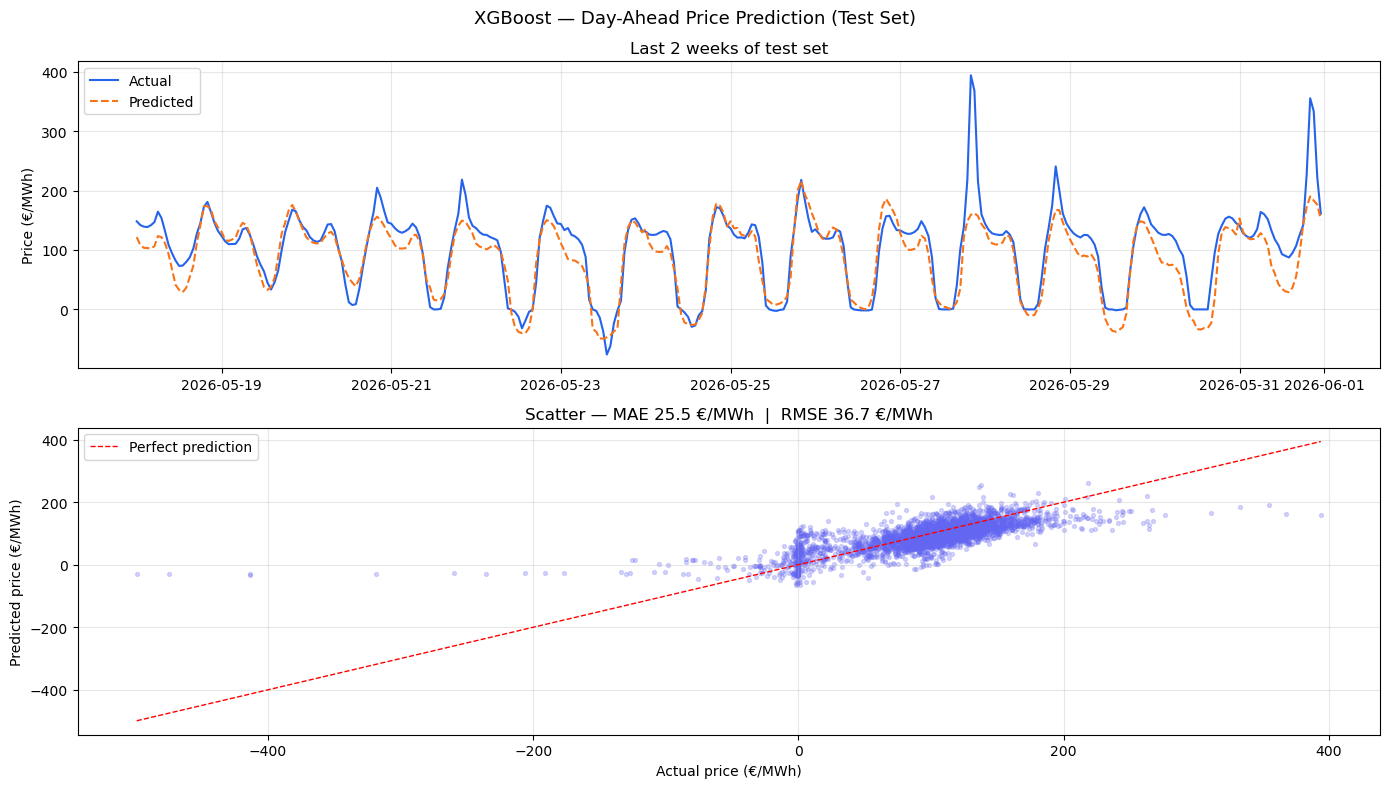

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("XGBoost — Day-Ahead Price Prediction (Test Set)", fontsize=13)

# Top: last 2 weeks for readability
ax = axes[0]
tail = 14 * 24
ax.plot(y_test.index[-tail:], y_test.values[-tail:],
        label="Actual", color="#2563eb", linewidth=1.5)
ax.plot(y_test.index[-tail:], y_pred[-tail:],
        label="Predicted", color="#f97316", linewidth=1.5, linestyle="--")
ax.set_title("Last 2 weeks of test set")
ax.set_ylabel("Price (€/MWh)")
ax.legend()
ax.grid(alpha=0.3)

# Bottom: scatter — perfect model sits on the diagonal
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.25, s=8, color="#6366f1")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax2.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax2.set_xlabel("Actual price (€/MWh)")
ax2.set_ylabel("Predicted price (€/MWh)")
ax2.set_title(f"Scatter — MAE {mae:.1f} €/MWh  |  RMSE {rmse:.1f} €/MWh")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Hyperparameter Tuning (Optuna)

In [18]:
# Hyperparameter Tuning with Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import lightgbm as lgb

def objective(trial):
    params = {
        "objective":             "reg:squarederror",
        "eval_metric":           "rmse",
        "early_stopping_rounds": 50,
        "n_estimators":          2000,
        "random_state":          42,
        "n_jobs":                -1,
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.02, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 6),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.1, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.5, 5.0, log=True), 
    }

    model_trial = xgb.XGBRegressor(**params)
    model_trial.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    preds_val  = model_trial.predict(X_val)
    preds_test = model_trial.predict(X_test)
    return (mean_absolute_error(y_val, preds_val) + 
        mean_absolute_error(y_test, preds_test)) / 2  

# Run optimization 
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\nBest MAE  : {study.best_value:.3f} €/MWh")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<25} {v}")

# Retrain final model with best params
best_params = {
    **study.best_params,
    "objective":             "reg:squarederror",
    "eval_metric":           "rmse",
    "early_stopping_rounds": 200,
    "n_estimators":          5000,
    "random_state":          42,
    "n_jobs":                -1,
}

model = xgb.XGBRegressor(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print(f"\nBest iteration : {model.best_iteration}")
joblib.dump(model, "smard_xgb_model_tuned.pkl")
print("Tuned model saved → smard_xgb_model_tuned.pkl") 

  0%|          | 0/200 [00:00<?, ?it/s]


Best MAE  : 23.529 €/MWh
Best params:
  learning_rate             0.012216453995304551
  max_depth                 6
  subsample                 0.6070042199177373
  colsample_bytree          0.5361358754113541
  min_child_weight          9
  reg_alpha                 2.3488909060158583
  reg_lambda                4.189034700248552
[0]	validation_0-rmse:47.82955
[50]	validation_0-rmse:39.13021
[100]	validation_0-rmse:35.54631
[150]	validation_0-rmse:34.09577
[200]	validation_0-rmse:33.51824
[250]	validation_0-rmse:33.20546
[300]	validation_0-rmse:33.09309
[350]	validation_0-rmse:33.01214
[400]	validation_0-rmse:32.98561
[450]	validation_0-rmse:32.99201
[500]	validation_0-rmse:33.01039
[550]	validation_0-rmse:32.98530
[600]	validation_0-rmse:33.01304
[650]	validation_0-rmse:33.03646
[700]	validation_0-rmse:33.04864
[727]	validation_0-rmse:33.05302

Best iteration : 527
Tuned model saved → smard_xgb_model_tuned.pkl


In [19]:
test_preds_tuned = model.predict(X_test)
print(f"Test MAE (tuned): {mean_absolute_error(y_test, test_preds_tuned):.2f} €/MWh")

Test MAE (tuned): 25.60 €/MWh


## SHAP Feature Importance

Shows not just which features matter but in which direction — high wind forecast pushes price down, high price last week pushes it up.

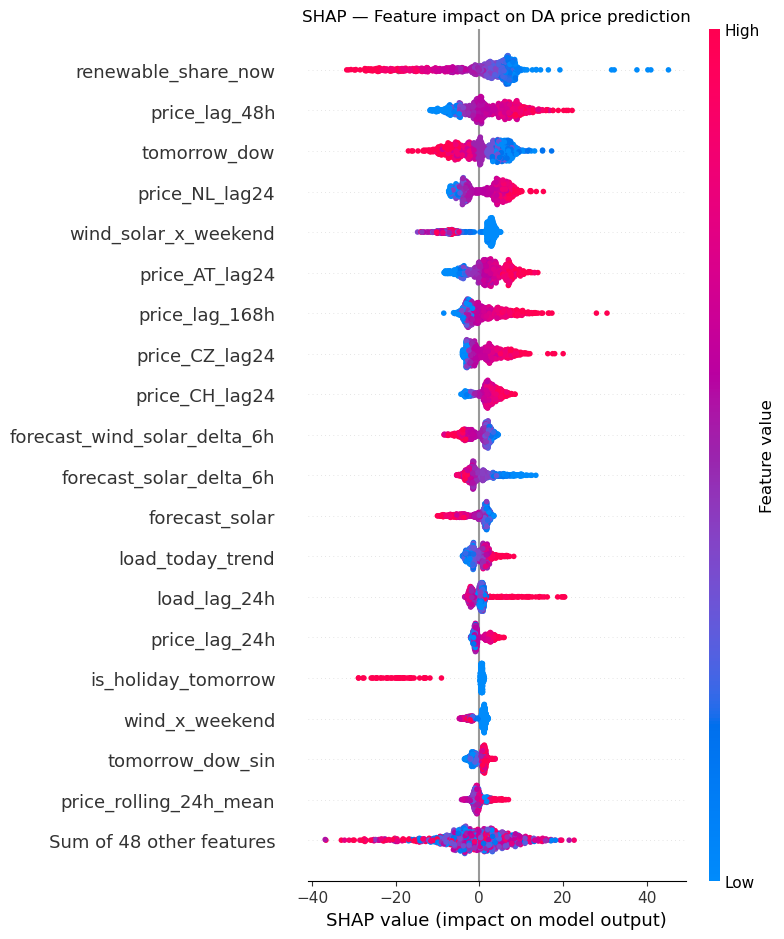

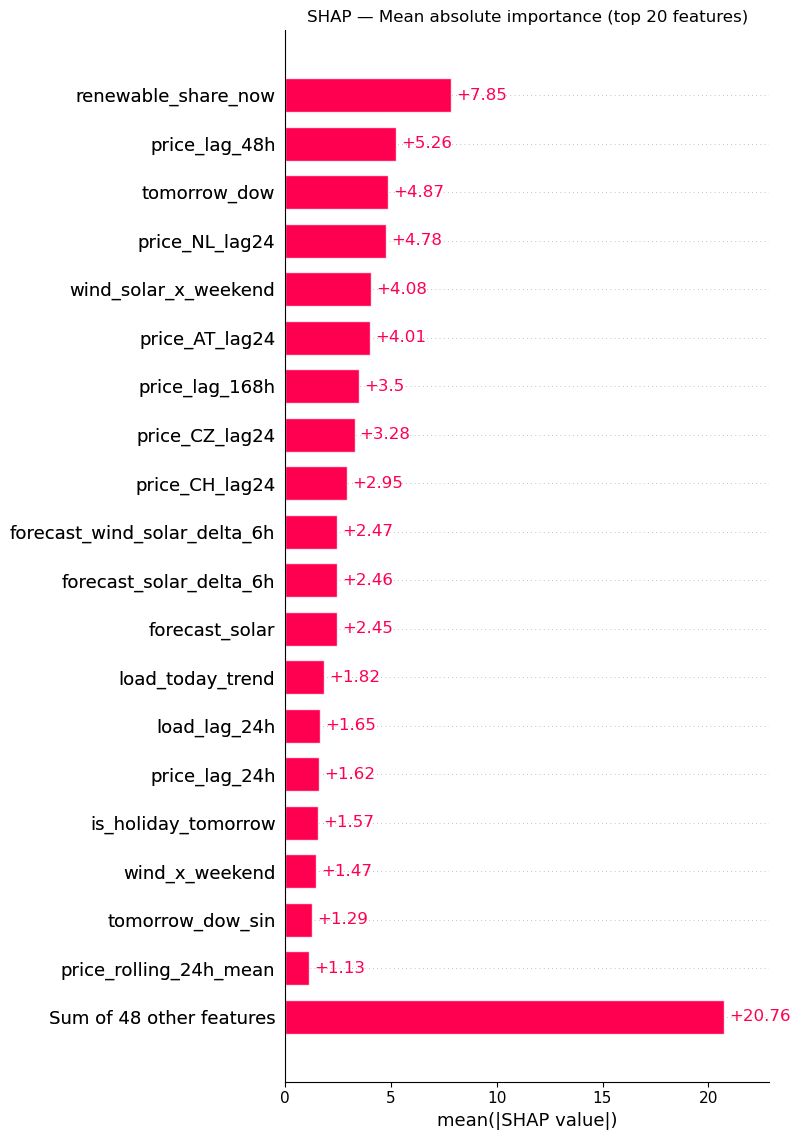


Top 10 features by mean |SHAP|:
   1. renewable_share_now                 7.853
   2. price_lag_48h                       5.258
   3. tomorrow_dow                        4.874
   4. price_NL_lag24                      4.781
   5. wind_solar_x_weekend                4.080
   6. price_AT_lag24                      4.015
   7. price_lag_168h                      3.504
   8. price_CZ_lag24                      3.283
   9. price_CH_lag24                      2.945
  10. forecast_wind_solar_delta_6h        2.467


In [20]:
explainer = shap.Explainer(model)


X_shap      = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer(X_shap)   # returns Explanation object

# Summary plot — beeswarm shows direction and magnitude
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False,
)
plt.title("SHAP — Feature impact on DA price prediction", fontsize=12)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


# Bar chart — mean absolute SHAP (pure importance, no direction)
plt.figure(figsize=(9, 7))
shap.plots.bar(
    shap_values,
    max_display=20,
    show=False,
)
plt.title("SHAP — Mean absolute importance (top 20 features)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 10 as text too
mean_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print("\nTop 10 features by mean |SHAP|:")
for i, (feat, val) in enumerate(mean_shap.head(10).items(), start=1):
    print(f"  {i:>2}. {feat:<35} {val:.3f}")


## Live Prediction — Tomorrow's 24h Curve

Run this every morning before 12:00 CET to get tomorrow's DA prices.

df_live shape: (24, 114)
Day-Ahead price forecast — tomorrow
Uncertainty band: ± 25.5 €/MWh (= test MAE)

                  hour  predicted_price  pred_low  pred_high
timestamp                                                   
2026-06-01 00:00     0           164.79    139.29     190.29
2026-06-01 01:00     1           154.70    129.20     180.19
2026-06-01 02:00     2           150.82    125.32     176.31
2026-06-01 03:00     3           150.04    124.54     175.54
2026-06-01 04:00     4           155.00    129.50     180.50
2026-06-01 05:00     5           152.45    126.95     177.95
2026-06-01 06:00     6           155.26    129.76     180.76
2026-06-01 07:00     7           138.37    112.88     163.87
2026-06-01 08:00     8           115.30     89.80     140.79
2026-06-01 09:00     9            82.83     57.33     108.33
2026-06-01 10:00    10            73.99     48.49      99.49
2026-06-01 11:00    11            66.77     41.27      92.27
2026-06-01 12:00    12            66.37 

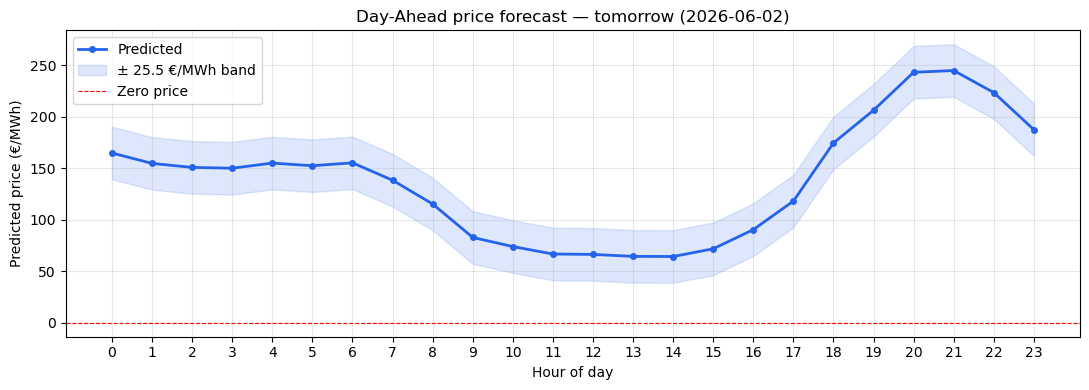

In [27]:
today    = pd.Timestamp.now(tz="Europe/Berlin").date()
tomorrow_date = today + pd.Timedelta(days=1)

df_live = df[df.index.date == tomorrow_date].copy()

if df_live.empty:
    print("No data for tomorrow yet")
else:
    print(f"df_live shape: {df_live.shape}")
    X_live = df_live[FEATURE_COLS].ffill().fillna(0)
    tomorrow_prices = model.predict(X_live)
    
    result = pd.DataFrame({
        "hour": df_live.index.hour,
        "predicted_price": tomorrow_prices.round(2),
        "pred_low": (tomorrow_prices - GLOBAL_MAE_BAND).round(2),
        "pred_high": (tomorrow_prices + GLOBAL_MAE_BAND).round(2),
    }, index=df_live.index.strftime("%Y-%m-%d %H:%M"))

    X_live = df_live[FEATURE_COLS].ffill().fillna(0)
    tomorrow_prices = model.predict(X_live)

    result = pd.DataFrame({
        "hour"           : df_live.index.hour,
        "timestamp"      : df_live.index,
        "predicted_price": tomorrow_prices.round(2),
        "pred_low"       : (tomorrow_prices - GLOBAL_MAE_BAND).round(2),
        "pred_high"      : (tomorrow_prices + GLOBAL_MAE_BAND).round(2),
    }).set_index("timestamp")

    #result.index = (df_live.index + pd.Timedelta(days=1)).strftime("%Y-%m-%d %H:%M")
    result.index = df_live.index.strftime("%Y-%m-%d %H:%M")

    print(f"Day-Ahead price forecast — tomorrow")
    print(f"Uncertainty band: ± {GLOBAL_MAE_BAND:.1f} €/MWh (= test MAE)")
    print()
    print(result[["hour", "predicted_price", "pred_low", "pred_high"]].to_string())
    print()
    print(f"  Min  : {result['predicted_price'].min():.2f} €/MWh  "
          f"(hour {result['predicted_price'].idxmin()[:13]})")
    print(f"  Max  : {result['predicted_price'].max():.2f} €/MWh  "
          f"(hour {result['predicted_price'].idxmax()[:13]})")
    print(f"  Mean : {result['predicted_price'].mean():.2f} €/MWh")

    plt.figure(figsize=(11, 4))
    plt.plot(result["hour"], result["predicted_price"],
             marker="o", markersize=4, color="#2563eb", linewidth=2,
             label="Predicted")
    plt.fill_between(result["hour"],
                     result["pred_low"],
                     result["pred_high"],
                     alpha=0.15, color="#2563eb", label=f"± {GLOBAL_MAE_BAND:.1f} €/MWh band")
    plt.axhline(0, color="red", linewidth=0.8, linestyle="--", label="Zero price")
    plt.xlabel("Hour of day")
    plt.ylabel("Predicted price (€/MWh)")
    plt.title(f"Day-Ahead price forecast — tomorrow "
              f"({(df_live.index[0] + pd.Timedelta(days=1)).date()})")
    plt.xticks(range(0, 24))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("tomorrow_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()

## Model Health Monitoring

Daily drift check: compare recent predictions against actuals, check for regime shifts, decide whether to retrain.

In [28]:


import sys
sys.path.append(".")  # ensure smard_monitor.py is found in current directory

from smard_monitor import (
    load_log,
    print_performance_trend,
    print_recent_alerts,
    should_retrain,
)

# Performance history
log = load_log()
print_performance_trend(log)
print_recent_alerts(log)

# Live regime shift check 
# Compare recent 30-day mean vs full historical mean
# A large difference signals the market has entered a new pricing regime
recent_mean     = df["price_DE_LU"].tail(30 * 24).mean()
historical_mean = df["price_DE_LU"].mean()
regime_diff     = abs(recent_mean - historical_mean)

print(f"\n  Regime check (live):")
print(f"  Recent 30d mean   : {recent_mean:.1f} €/MWh")
print(f"  Historical mean   : {historical_mean:.1f} €/MWh")
print(f"  Difference        : {regime_diff:.1f} €/MWh")

if regime_diff > 30:
    print(f"  CRITICAL: regime shift detected → retrain recommended")
elif regime_diff > 15:
    print(f"  WARNING: market conditions changing → monitor closely")
else:
    print(f"  OK: market conditions stable")

# Retrain decision
# Retrain if: Monday (weekly schedule) OR MAE too high OR regime shift
retrain_needed = should_retrain(log, mae, regime_diff)
if retrain_needed:
    print("\n  Action: python smard_monitor.py --retrain")
else:
    print("\n  Action: no retrain needed today")


  No performance history yet.

  No alerts in history.

  Regime check (live):
  Recent 30d mean   : 104.0 €/MWh
  Historical mean   : 86.6 €/MWh
  Difference        : 17.4 €/MWh

  → No retrain needed today

  Action: no retrain needed today
